# Статистика, DS-поток
## Марафон-домашка SM.8, практическая часть

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.



**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание.**

* Задача 1 &mdash; 30 баллов;
* Задача 2 &mdash; 90 баллов;


**Важность задач:**

* *высокая:* задачи 1,2;

**ДЗ будет дополнено.**



In [ ]:
# Bot check

# HW_ID: ds_sm8
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [233]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid", font_scale=1.3, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])

from statsmodels.stats.diagnostic import lilliefors
from statsmodels.stats.multitest import multipletests

In [4]:
import base64
from IPython.display import Markdown, display
def embed_image(filename):
    with open(filename, "rb") as f:
        data = base64.b64encode(f.read()).decode()
    md = f'<img src="data:image/png;base64,{data}" width="800">'
    display(Markdown(md))

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована

_____
### Задача 1

Пусть $X_1, ..., X_n \sim Bern(p)$.
Известно, что $S_n = \left\{\sum_{i=1}^n x_i > c_{n,\alpha}\right\}$ является равномерно наиболее мощным критерием для проверки $\mathsf{H}_0\colon p=1/2\ vs.\ \mathsf{H}_1\colon p>1/2$, где $\alpha$ &mdash; уровень значимости.

Некоторая компания решила воспользоваться этим критерием для решения одной своей задачи. Например, это может быть исследование конверсии в клик, заполнении формы, указания номера телефона, и тд. Конверсия &mdash; доля пользователей, которая совершит определенное целевое действие.

Данные приходят онлайн, но не так часто. Для простоты задачи будем считать, что данные приходят по одному наблюдению в сутки. Однако, маркетологи не хотят долго ждать, и решают проверять гипотезу каждый день с помощью имеющихся на текущий момент данных.
То есть в $k$-й день они пользуются критерием $S_k$, имея выборку $X_1, ..., X_k$.
Если же в один из дней соответствующий критерий дает положительный результат (т.е. отклоняет $\mathsf{H}_0$), то маркетологи завершают наблюдения, иначе &mdash; продолжают тестирование.

Промоделируйте подобную процедуру в течение 100 дней в предположении справедливости $\mathsf{H}_0$.

In [74]:
alpha = 0.05
p = 0.5
n_days = 100

n_range = range(1, n_days + 1)
for n in n_range:
    t = sps.binom(n=n, p=p).rvs()
    c = sps.binom(n=n, p=p).ppf(1 - alpha)
    if t > c:
        print(f'Тестирование прервано в день {n}')
        break

if n == n_days:
    print('Тестирование не обнаружило статически значимого результата')

Тестирование прервано в день 13


Повторите данный эксперимент достаточное количество раз и по результатам оцените вероятность ошибки I рода в случае если компания проводит эксперимент не более $n$ дней. Постройте ее график в зависимости от $n$.

In [124]:
m = 10_000

res = []
for i in tqdm(range(m)):
    for n in n_range:
        t = sps.binom(n=n, p=p).rvs()
        c = sps.binom(n=n, p=p).ppf(1 - alpha)
        if t > c:
            res.append(n)
            break

  0%|          | 0/10000 [00:00<?, ?it/s]

Выполним небольшую предобработку

In [129]:
uniqs, counts = np.unique(res, return_counts=True)
for i in range(1, len(counts)):
    counts[i] += counts[i - 1]

uniqs, counts = uniqs.tolist(), counts.tolist()
for n in n_range:
    if n not in uniqs:
        uniqs.insert(n - 1, n)
        counts.insert(n - 1, 0)

Результаты ниже

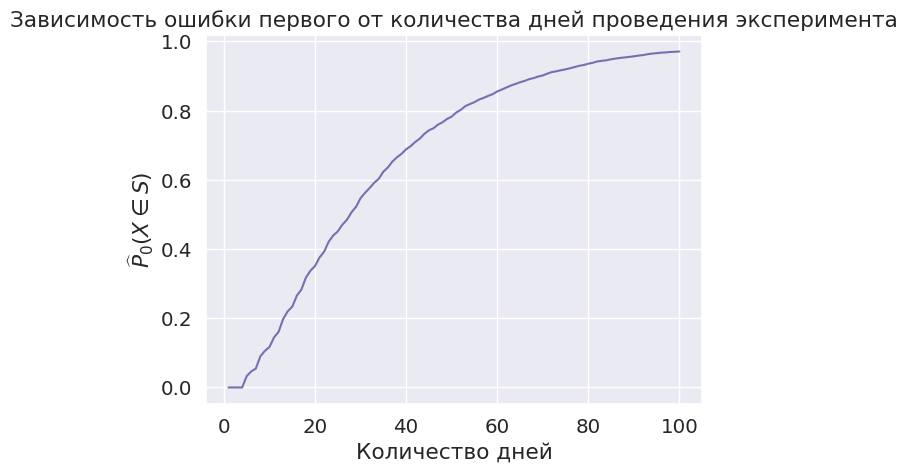

In [135]:
probs = np.array(counts) / m
plt.plot(uniqs, probs)
plt.title('Зависимость ошибки первого от количества дней проведения эксперимента')
plt.xlabel('Количество дней')
plt.ylabel(r'$\widehat{P}_0(X \in S)$')
plt.show()

Сделайте выводы

Видим, что при таком проведении ээксперимента с ростом количества дней мы всё хуже контроллируем ошибку первого рода, а точнее она не контроллируема вследствие множественной проверки гипотезы. При такой постановке задачи вероятность с ростом выборки и должна быть около 1. Однако при первых 4 тестах гипотеза не отвергалась

*Замечание.* В статистике (в т.ч. в АБ-тестировании) подобный эффект называется *проблемой подглядывания* (peeking problem). Размер выборки для применения критерия должен быть определен заранее, его нельзя как-то сокращать на основе полученных данных, даже если бизнесу очень хочется.

___________
### Задача 2

*Примечание.* Задача достаточно простая, кода здесь мало. Основное количество баллов дается за ответы на вопросы. Не забывайте также смотреть в ноутбуки с семинаров.

Cкачайте данные <a href="http://archive.ics.uci.edu/ml/datasets/wine">`wine dataset`</a>, взяв все признаки, кроме `Class`.

In [138]:
X = pd.read_csv("wine.data", header=None)

X.columns = [
    "Class",
    "Alcohol",
    "Malic acid",
    "Ash",
    "Alcalinity of ash",
    "Magnesium",
    "Total phenols",
    "Flavanoids",
    "Nonflavanoid phenols",
    "Proanthocyanins",
    "Color intensity",
    "Hue",
    "OD280/OD315 of diluted wines",
    "Proline"
]

X = X.drop(['Class'], axis=1)
X.head(3)

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185


Для каждого из признаков нарисуйте Q-Q plot. Для наглядности и экономии места рисуйте графики в несколько столбцов, используя `plt.subplot`.

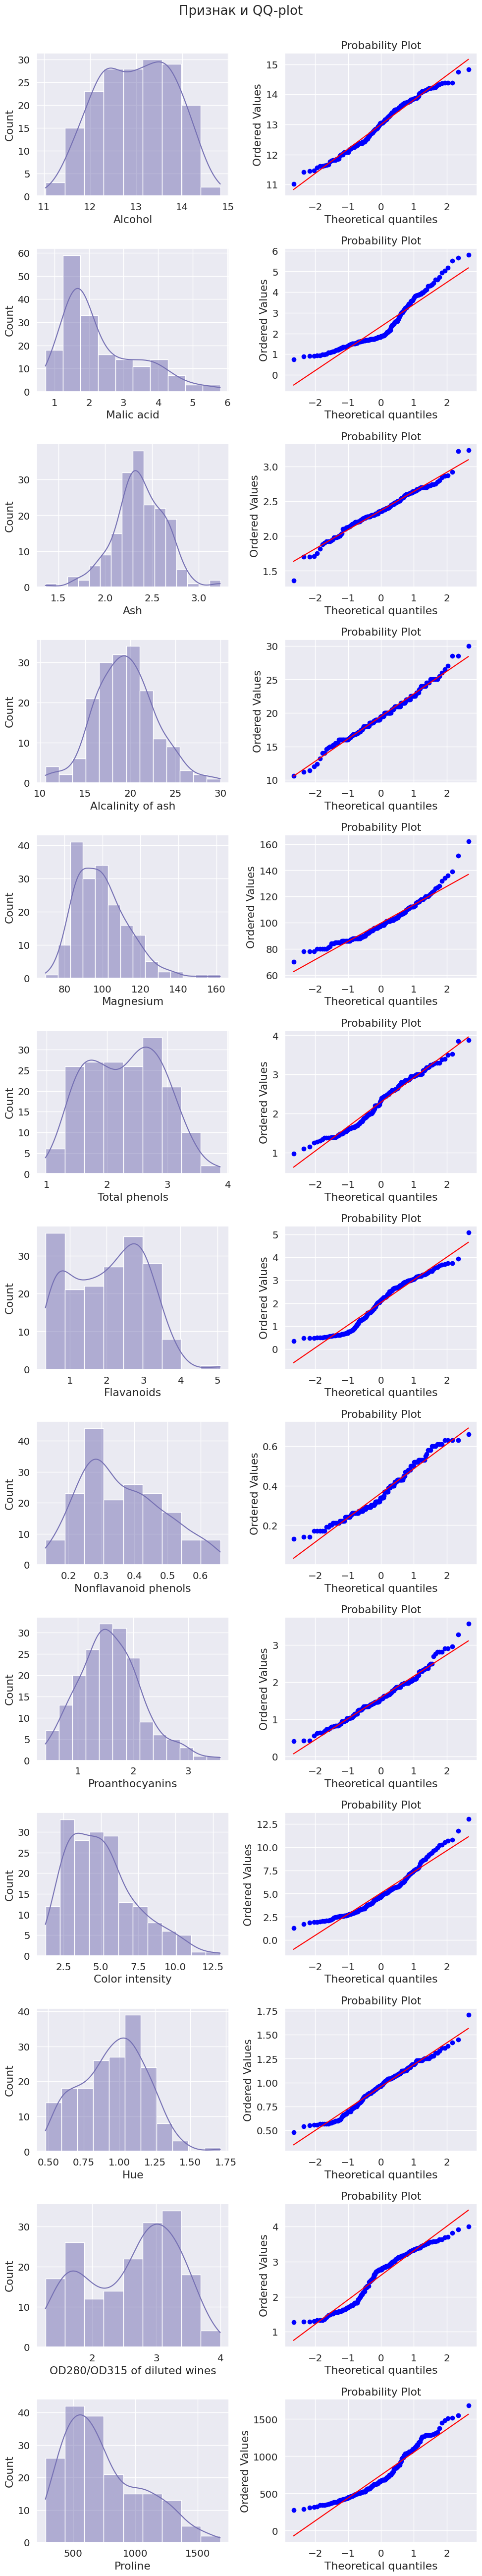

In [167]:
m = len(X.columns)
fig, ax = plt.subplots(nrows=m, ncols=2, figsize=(10, 4*m))

for i, column in enumerate(X.columns):
    sns.histplot(X[column], ax=ax[i][0], kde=True)
    sps.probplot(X[column], dist='norm', plot=ax[i][1])
plt.suptitle('Признак и QQ-plot', y=1)
plt.tight_layout()
plt.show()

Для каких признаков можно говорить об их нормальности и почему?

**Ответ:** 

Alcohol. Центр немного s-образный, хвосты отстают: плосковершинность, однако симметричный, похож на нормальное.

Ash. Хвосты немного вогнуты вниз: левосторонная асимметрия, есть выбросы, но в целом похоже на нормальное.

Alcanit of ash: Хвосты немного вогнуты вверх: правосторонная асимметрия, есть выбросы, в остальном всё нормально.

Проверьте нормальность каждого признака статистическими критериями. Прежде чем выполнить следующую часть задачи, ответьте на вопросы. Помочь в этом может теоретический материал и выполненные ранее задачи.

Для каждого признака используйте несколько критериев проверки нормальности. Какие критерии вы будете использовать?

In [168]:
X.shape

(178, 13)

**Ответ:** Размеры выборки позволяют использовать критериий Шапиро-Уилка, являющийся чаще всего наиболее мощным, но у которого при малых размерах выборки высокий реальный уровень значимости, и Жарка-Бера, который хорошо отлваливает тяжелые хвосты (см. SM7p). Возьмём также критерий Лиллиефорса

Результаты критериев нужно обработать с помощью *одной* процедуры множественной проверки гипотез для всех признаков и всех критериев сразу. Почему так нужно делать?

**Ответ:** У нас много гипотез, на основе их мы хотим сделать коллективный вывод, основываясь на результатах всех критериев (то есть учитывая различные свойства исследуемого распрделения признака и учитывая различные признаки: нас интересует вся информация о вине)

Какой метод для контроля FWER стоит применить и почему?

**Ответ:** В данном случае занимаемся подтверждением гипотезы, поэтому оптимально использовать FWER для контроля ошибки первого рода. Далее зависит от условий заказчика, тут будем рассуждать логически. Мы анализируем датасет из вин, насколько распрделение признаков нормальное. Нас интересует толер к ложноположительному срабатыванию. Тут скорее зависит от объёма последующих после нашего решений инвестиций и убытков. В целом наши тесты могут быть зависимыми, так как даже с точки зрения реальной жизни одни характеристики вина могут повлиять на другие, но взглянем также на матрицу корреляций Спирмена

Взглянем на матрицу корреляций Спирмена, чтобы понять, какие есть зависимости среди признаков 

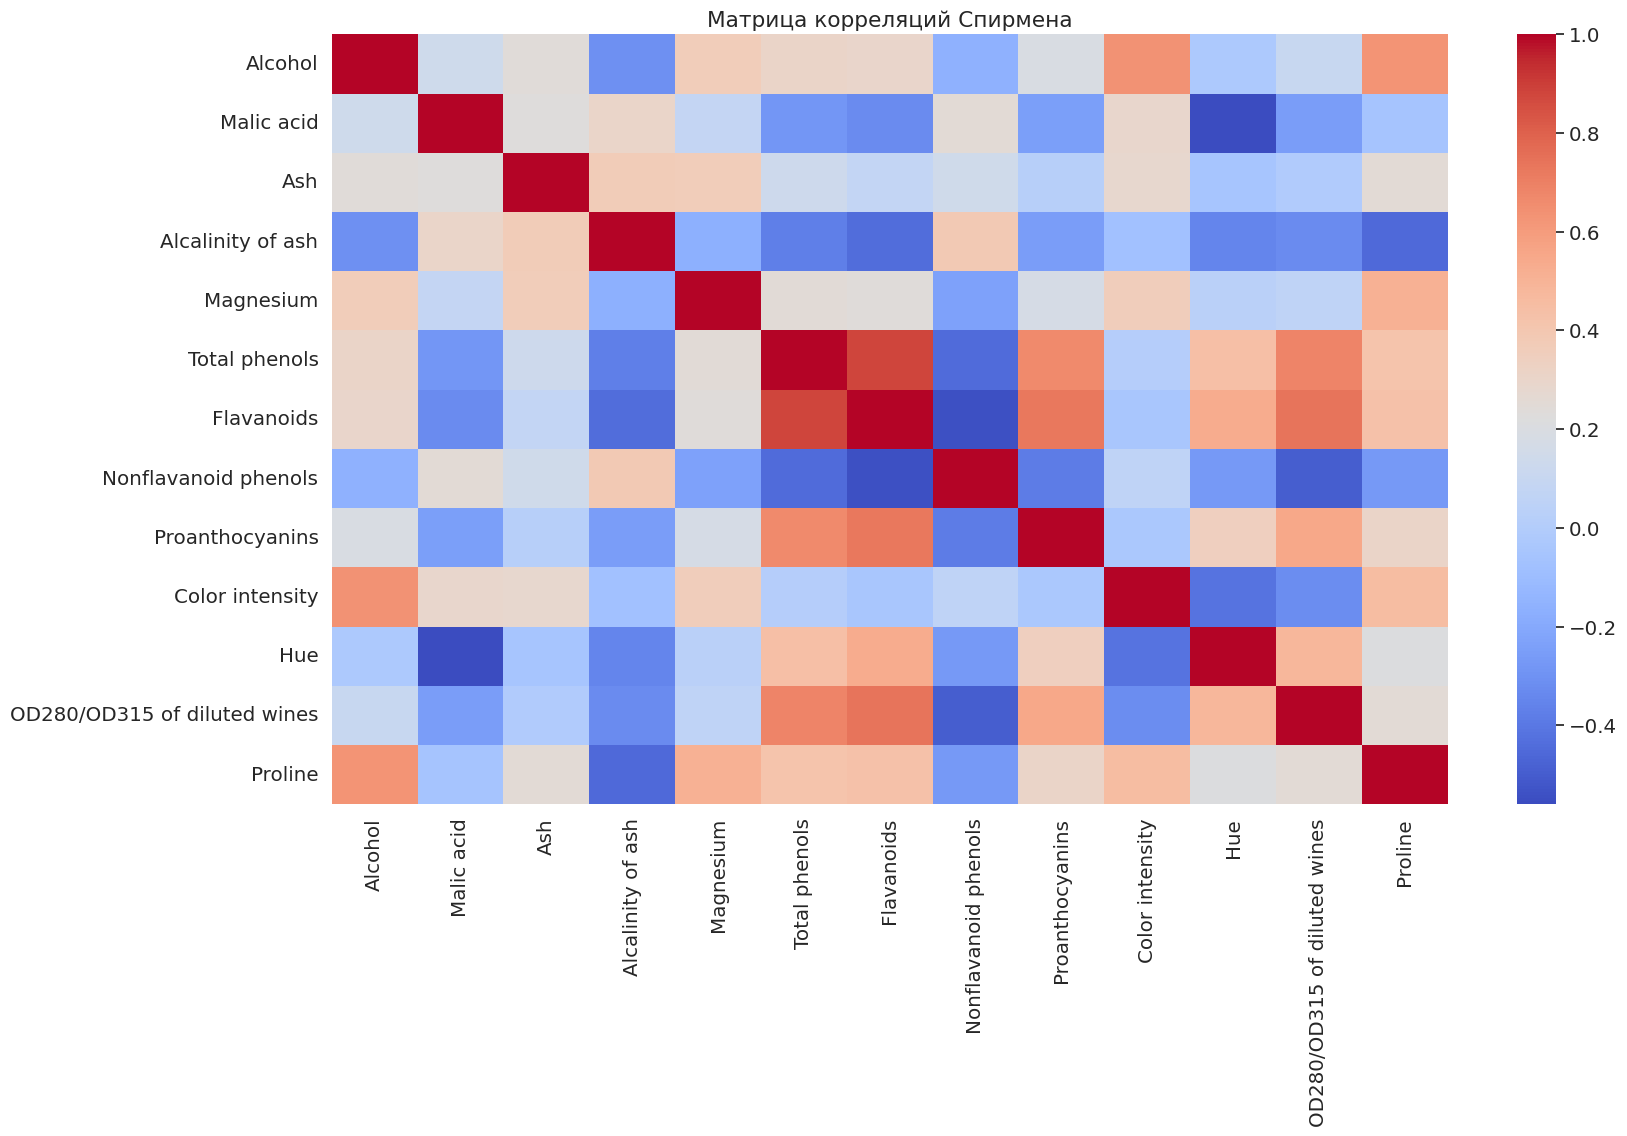

In [182]:
corr = X.corr(method='spearman')
plt.figure(figsize=(18, 10))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Матрица корреляций Спирмена')
plt.show()

Видим, что тесты не независимы. Сами тесты могут также обращать внимания на пересекающиеся свойства, поэтому вне зависимости от толера возьмём мощный метод Холма. Сравним также с Бонферони, который используется в случае зависимых тестов и наличия толерантности

Как понять из результата процедуры множественной проверки гипотез, нормальность каких признаков следует отклонить?

**Ответ:** Нужно получить p_value нормальности всех признаков для каждого из критериев, затем для этих p_value и соотвествующих гипотез провести тест одним из методов

Если нормальность не отклоняется, что можно сказать про выборку? Ответ находится в презентации с лекции.

**Ответ:** Значит либо распрделение нормальное, либо наш критерий недостаточно мощный. Выборка согласуется с основной гипотезой

Реализуйте данную схему. Предварительно соберите p-value всех критериев в таблицу.

Функция `multipletests` принимает только одномерные массивы, поэтому для полученной `numpy`-таблицы нужно воспользоваться методом `ravel`. Результаты соберите обратно в таблицу с помощью метода `reshape`, которому необходимо передать размерности таблицы. Для наглядности сделайте таблицу с помощью `pandas.DataFrame`. В качестве названий строк используйте названия признаков, а названий столбцов — используемые критерии. В таблице должны присутстововать как значения p-value, так и результат проверки (`True` в случае отвержения).

In [226]:
df = pd.DataFrame(columns=['Лиллиефорса', 'Шапиро-Уилка', 'Жарка-Бера'], index=X.columns)

for column in X.columns:
    lil = lilliefors(X[column])[1]
    shap = sps.shapiro(X[column])[1]
    jarq = sps.jarque_bera(X[column])[1]
    df.loc[column] = [(np.round(lil, 3), lil<0.05), (np.round(shap, 3), shap<0.05), (np.round(jarq, 3), jarq<0.05)]

In [227]:
df

,Лиллиефорса,Шапиро-Уилка,Жарка-Бера
Alcohol,"(0.058, False)","(0.02, True)","(0.061, False)"
Malic acid,"(0.001, True)","(0.0, True)","(0.0, True)"
Ash,"(0.187, False)","(0.039, True)","(0.008, True)"
Alcalinity of ash,"(0.099, False)","(0.264, False)","(0.251, False)"
Magnesium,"(0.002, True)","(0.0, True)","(0.0, True)"
Total phenols,"(0.035, True)","(0.004, True)","(0.063, False)"
Flavanoids,"(0.005, True)","(0.0, True)","(0.053, False)"
Nonflavanoid phenols,"(0.001, True)","(0.0, True)","(0.011, True)"
Proanthocyanins,"(0.217, False)","(0.014, True)","(0.008, True)"
Color intensity,"(0.002, True)","(0.0, True)","(0.0, True)"


In [243]:
x = df.to_numpy()
x = [tup[0] for tup in x.ravel()]
reject, pvals, _, _ = multipletests(x, method='holm')
pd.DataFrame(columns=['Лиллиефорса', 'Шапиро-Уилка', 'Жарка-Бера'], index=X.columns, data=reject.reshape(-1, 3))

,Лиллиефорса,Шапиро-Уилка,Жарка-Бера
Alcohol,False,False,False
Malic acid,True,True,True
Ash,False,False,False
Alcalinity of ash,False,False,False
Magnesium,True,True,True
Total phenols,False,False,False
Flavanoids,False,True,False
Nonflavanoid phenols,True,True,False
Proanthocyanins,False,False,False
Color intensity,True,True,True


Для каких признаков нормальность не отвергается?

**Ответ:** Alcohol, Ash, , Alcalinity of ash, Total phenols, Proanthocyanins, Hue

**Вывод:** Видим, что в результате множественного тестирования часть отвергаемых гипотез перестала быть статистически значимой, так как уменьшился $\alpha$, p-value ниже которого гипотезы отвергается. Также такой метод позволил отобрать больше выборок, согласаующихся с нормальным рапсрделением, чем при визуальном анализе QQ-plot. В целом более осмысленный и сторгий результат.

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока